# Exercise 5 — Text Classification with Transformers
### Sarcasm Detector

---

## The Problem

A news aggregation platform wants to automatically flag sarcastic headlines
before surfacing them in serious news feeds — sarcastic content mixed into
factual news erodes reader trust.

You are given a dataset of real news headlines labeled as sarcastic or not.
Build a binary text classifier using a pretrained transformer.

---

## The Data

```python
!pip install transformers opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")
```

A JSON file where each line is a headline with an `is_sarcastic` label (0 or 1)
and the source `article_link`. The column you need is `headline`.

⚠️ **One thing worth knowing:** this is a large dataset. If training is slow,
start with a subset to verify your pipeline works before scaling up.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A fine-tuned transformer model** (from HuggingFace) that classifies
   headlines as sarcastic or not
2. **A clear statement** of which pretrained model you used, which weights
   you froze, and what classification head you added — and why
3. **A training report** — loss and accuracy curves for train and validation
4. **A test accuracy score**
5. **A live inference demo** — given any headline string,
   the model returns sarcastic or not sarcastic

You must use `AutoTokenizer` and `AutoModel` from the `transformers` library.
The model choice, head architecture, and training decisions are yours.

---

In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import random
from pathlib import Path
from typing import Dict, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig
from typing import Dict

# HuggingFace imports (we will use these heavily in Step 3)
from transformers import AutoTokenizer, AutoModel

print("✅ HuggingFace and PyTorch libraries installed and imported successfully!")
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

✅ HuggingFace and PyTorch libraries installed and imported successfully!


In [7]:
# --- Master Configuration ---
CONFIG = {
    "dataset_name": "rmisra/news-headlines-dataset-for-sarcasm-detection",
    "text_col": "headline",
    "label_col": "is_sarcastic",
    "max_length": 64,         # Headlines are short; 64 tokens is usually plenty
    "batch_size": 32,           
    "learning_rate": 1e-5,    # Standard LR for fine-tuning Transformers
    "num_epochs": 6,          # Transformers converge very quickly
    "weight_decay": 0.05,     # Helps prevent overfitting in Transformers
    "seed": 42,
    "num_workers": 2,
    "subset_size": 5000,
    "dropout_rate": 0.5      # We will start with a subset to verify the pipeline quickly
}

# --- Environment Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])

print(f" Using device: {DEVICE}")
print(f" Max Token Length: {CONFIG['max_length']}")

 Using device: cuda
 Max Token Length: 64


In [8]:
def get_dataset_and_load_json(dataset_name: str) -> pd.DataFrame:
    """
    Downloads the dataset using kagglehub (skips if cached) 
    and loads the JSONL file correctly.
    """
    print(f"📥 Checking/Downloading dataset '{dataset_name}'...")
    path = Path(kagglehub.dataset_download(dataset_name))
    print(f"✅ Dataset available at: {path}")
    
    # Find the JSON file dynamically (usually named Sarcasm_Headlines_Dataset_v2.json)
    json_files = list(path.glob("*.json"))
    
    if not json_files:
        raise FileNotFoundError("No .json files found in the downloaded dataset directory!")
        
    json_path = json_files[0]
    print(f"📄 Found JSON file: {json_path.name}")
    
    # CRITICAL: lines=True is required for JSONL format!
    print("⏳ Loading JSONL file (this might take a minute)...")
    df = pd.read_json(json_path, lines=True)
    
    return df

# Execute download and load
df_full = get_dataset_and_load_json(CONFIG['dataset_name'])

# Sanity Check
print(f"\n📊 Dataset Shape: {df_full.shape}")
print(f"📋 Columns found: {df_full.columns.tolist()}")
print("\n First 5 rows:")
print(df_full.head())

📥 Checking/Downloading dataset 'rmisra/news-headlines-dataset-for-sarcasm-detection'...
Using Colab cache for faster access to the 'news-headlines-dataset-for-sarcasm-detection' dataset.
✅ Dataset available at: /kaggle/input/news-headlines-dataset-for-sarcasm-detection
📄 Found JSON file: Sarcasm_Headlines_Dataset_v2.json
⏳ Loading JSONL file (this might take a minute)...

📊 Dataset Shape: (28619, 3)
📋 Columns found: ['is_sarcastic', 'headline', 'article_link']

 First 5 rows:
   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

                                        article_link  
0  https://www.theonion.com/thirtysomething

In [9]:
def plot_class_distribution(df: pd.DataFrame, label_col: str) -> None:
    """
    Plots the distribution of the target classes to check for imbalance.
    """
    print("📊 Plotting Class Distribution...")
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=label_col, palette='viridis')
    plt.title('Class Distribution: Sarcastic vs Non-Sarcastic', fontsize=12, fontweight='bold')
    plt.xlabel('Is Sarcastic (0 = No, 1 = Yes)')
    plt.ylabel('Count')
    
    # Add count labels on top of bars
    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
                           
    plt.tight_layout()
    plt.show()

def analyze_text_lengths(df: pd.DataFrame, text_col: str) -> None:
    """
    Analyzes the length of the text data (using word count as a fast proxy for token count).
    This is crucial for setting the Transformer's max_length parameter.
    """
    print("📏 Analyzing Text Lengths (Word Count)...")
    
    # Calculate word count for all headlines
    # Note: 1 word is roughly equal to 1.2 - 1.3 tokens in BERT/DistilBERT
    word_counts = df[text_col].apply(lambda x: len(str(x).split()))
    
    mean_len = word_counts.mean()
    p95_len = word_counts.quantile(0.95)
    p99_len = word_counts.quantile(0.99)
    max_len = word_counts.max()
    
    print(f"   Mean words: {mean_len:.1f}")
    print(f"   95th Percentile: {p95_len:.1f} words (~{p95_len * 1.3:.0f} tokens)")
    print(f"   99th Percentile: {p99_len:.1f} words (~{p99_len * 1.3:.0f} tokens)")
    print(f"   Maximum words: {max_len}")
    
    plt.figure(figsize=(10, 5))
    sns.histplot(word_counts, bins=50, kde=True, color='skyblue')
    plt.title('Distribution of Headline Lengths', fontsize=12, fontweight='bold')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    
    # Add reference lines
    plt.axvline(mean_len, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
    plt.axvline(p95_len, color='orange', linestyle='--', linewidth=2, label=f'95th %ile: {p95_len:.1f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

def create_pipeline_subset(df: pd.DataFrame, subset_size: int, seed: int) -> pd.DataFrame:
    """
    Creates a smaller subset of the data to quickly verify the pipeline 
    before committing to a full 30-minute training run.
    """
    print(f"📦 Creating sandbox subset of size {subset_size}...")
    df_subset = df.sample(n=subset_size, random_state=seed).reset_index(drop=True)
    print(f"✅ Subset created successfully! Shape: {df_subset.shape}")
    return df_subset

📊 Plotting Class Distribution...


/tmp/ipykernel_48683/3598777687.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_col, palette='viridis')


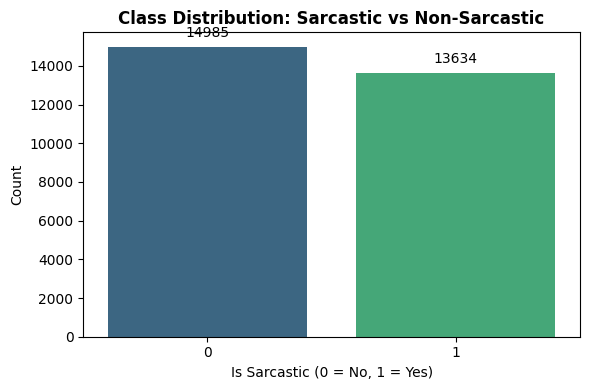

📏 Analyzing Text Lengths (Word Count)...
   Mean words: 10.0
   95th Percentile: 16.0 words (~21 tokens)
   99th Percentile: 19.0 words (~25 tokens)
   Maximum words: 151


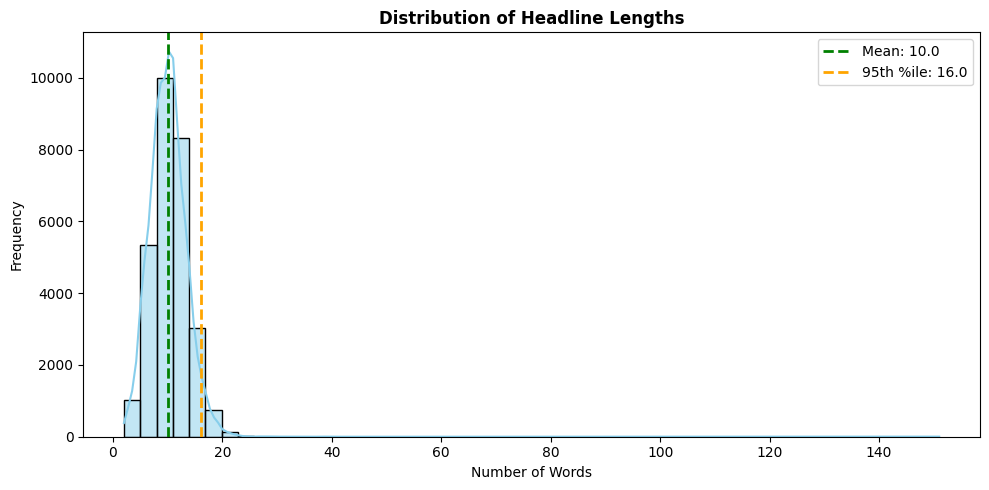

📦 Creating sandbox subset of size 5000...
✅ Subset created successfully! Shape: (5000, 3)


In [10]:
# 1. Check Class Balance
plot_class_distribution(df_full, CONFIG['label_col'])

# 2. Analyze Text Lengths (Validates our max_length=64 config)
analyze_text_lengths(df_full, CONFIG['text_col'])

# 3. Create the Sandbox Subset
# We will use this subset for Steps 3, 4, and 5 to test the pipeline quickly.
df_subset = create_pipeline_subset(df_full, CONFIG['subset_size'], CONFIG['seed'])

In [11]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"✅ Tokenizer loaded for '{MODEL_NAME}'")
print(f"   Vocabulary size: {tokenizer.vocab_size:,} tokens")

# 2. Stratified Train / Val / Test Split (80% / 10% / 10%)
# We use the sandbox subset (df_subset) to keep pipeline testing fast!
train_df, temp_df = train_test_split(
    df_subset, 
    test_size=0.2, 
    random_state=CONFIG['seed'], 
    stratify=df_subset[CONFIG['label_col']]
)
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=CONFIG['seed'], 
    stratify=temp_df[CONFIG['label_col']]
)

print(f"\n📊 Data Split Sizes:")
print(f"   Train: {len(train_df)}")
print(f"   Val:   {len(val_df)}")
print(f"   Test:  {len(test_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


✅ Tokenizer loaded for 'distilbert-base-uncased'
   Vocabulary size: 30,522 tokens

📊 Data Split Sizes:
   Train: 4000
   Val:   500
   Test:  500


In [12]:
class SarcasmDataset(Dataset):

    def __init__(
        self, 
        df: pd.DataFrame, 
        tokenizer: AutoTokenizer, 
        max_length: int
    ) -> None:
        # Store text and labels as lists for fast indexing
        self.texts = df[CONFIG['text_col']].tolist()
        self.labels = df[CONFIG['label_col']].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self) -> int:
        return len(self.texts)
        
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,  # Adds [CLS] and [SEP] tokens
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),       # Shape: [max_length]
            'attention_mask': encoding['attention_mask'].squeeze(0), # Shape: [max_length]
            'labels': torch.tensor(label, dtype=torch.long)      # Shape: [] (scalar)
        }

In [13]:
print("🔄 splitting the FULL dataset (28,619 samples)...")

# 1. Stratified Train / Val / Test Split on the FULL dataset
train_df_full, temp_df_full = train_test_split(
    df_full, 
    test_size=0.2, 
    random_state=CONFIG['seed'], 
    stratify=df_full[CONFIG['label_col']]
)
val_df_full, test_df_full = train_test_split(
    temp_df_full, 
    test_size=0.5, 
    random_state=CONFIG['seed'], 
    stratify=temp_df_full[CONFIG['label_col']]
)

print(f"   Train: {len(train_df_full)} | Val: {len(val_df_full)} | Test: {len(test_df_full)}")

# 2. create Datasets
train_dataset_full = SarcasmDataset(train_df_full, tokenizer, CONFIG['max_length'])
val_dataset_full = SarcasmDataset(val_df_full, tokenizer, CONFIG['max_length'])
test_dataset_full = SarcasmDataset(test_df_full, tokenizer, CONFIG['max_length'])

# 3. create DataLoaders
train_loader_full = DataLoader(
    train_dataset_full, batch_size=CONFIG['batch_size'], shuffle=True, 
    num_workers=CONFIG['num_workers'], pin_memory=True
)
val_loader_full = DataLoader(
    val_dataset_full, batch_size=CONFIG['batch_size'], shuffle=False, 
    num_workers=CONFIG['num_workers'], pin_memory=True
)
test_loader_full = DataLoader(
    test_dataset_full, batch_size=CONFIG['batch_size'], shuffle=False, 
    num_workers=CONFIG['num_workers'], pin_memory=True
)

print("✅ Full DataLoaders created successfully!")

🔄 splitting the FULL dataset (28,619 samples)...
   Train: 22895 | Val: 2862 | Test: 2862
✅ Full DataLoaders created successfully!


 # Define the Custom Transformer Classifie

In [14]:
class SarcasmTransformerClassifier(nn.Module):
    def __init__(
        self, 
        model_name: str, 
        num_classes: int = 2, 
        dropout_rate: float = CONFIG['dropout_rate']
    ) -> None:
        super(SarcasmTransformerClassifier, self).__init__()
        
        self.config = AutoConfig.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name)
        

        for param in self.transformer.transformer.layer[:4].parameters():
            param.requires_grad = False
        
        # Dropout prevents overfitting on the small subset of data
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # Linear layer maps the 768-dimensional [CLS] vector to our 2 classes
        self.classifier = nn.Linear(in_features=self.config.hidden_size, out_features=num_classes)

    def forward(
        self, 
        input_ids: torch.Tensor, 
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        # Pass the tokenized input through the Transformer
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_output = outputs.last_hidden_state[:, 0, :]
        
        # Apply dropout for regularization
        x = self.dropout(cls_output)
        
        logits = self.classifier(x)
        
        return logits

In [15]:
def count_parameters(model: nn.Module) -> tuple:
    """Counts trainable and total parameters."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

# 1. Instantiate the model (with the new freezing logic applied)
model_full = SarcasmTransformerClassifier(
    model_name=MODEL_NAME, 
    num_classes=2, 
    dropout_rate=CONFIG['dropout_rate']
).to(DEVICE)

# 2. Print Model Summary
trainable_params, total_params = count_parameters(model_full)
print("="*50)
print("TRANSFORMER ARCHITECTURE SUMMARY")
print("="*50)
print(f"Base Model: {MODEL_NAME}")
print(f"Hidden Size: {model_full.config.hidden_size}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,} (Partially Frozen to prevent overfitting)")
print("="*50)

# 3. Verify with a Real Batch from our FULL DataLoader
print("\n🔍 Verifying forward pass with a real batch...")
model_full.train() # Set to train mode to test dropout

# Grab one batch from our FULL training loader
batch = next(iter(train_loader_full))
input_ids = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
labels = batch['labels'].to(DEVICE)

with torch.no_grad():
    logits = model_full(input_ids=input_ids, attention_mask=attention_mask)

print(f"   Input IDs Shape:      {input_ids.shape}")
print(f"   Attention Mask Shape: {attention_mask.shape}")
print(f"   Output Logits Shape:  {logits.shape} <-- [Batch Size, Num Classes]")
print(f"   Sample Logits:        {logits[:3]}")
print("\n✅ Model successfully processes tokenized text and outputs raw logits!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TRANSFORMER ARCHITECTURE SUMMARY
Base Model: distilbert-base-uncased
Hidden Size: 768
Total Parameters: 66,364,418
Trainable Parameters: 38,012,930 (Partially Frozen to prevent overfitting)

🔍 Verifying forward pass with a real batch...
   Input IDs Shape:      torch.Size([32, 64])
   Attention Mask Shape: torch.Size([32, 64])
   Output Logits Shape:  torch.Size([32, 2]) <-- [Batch Size, Num Classes]
   Sample Logits:        tensor([[-0.0261, -0.5030],
        [ 0.2465, -0.6832],
        [-0.0727, -0.4782]], device='cuda:0')

✅ Model successfully processes tokenized text and outputs raw logits!


# Transformer Training Loop

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from typing import Tuple

def setup_transformer_training(model: nn.Module, config: dict) -> Tuple[nn.Module, optim.Optimizer, lr_scheduler.ReduceLROnPlateau]:

    # 1. Loss Function
    criterion = nn.CrossEntropyLoss()
    
    # 2. Optimizer (AdamW is the industry standard for Transformers)
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=config['learning_rate'], 
        weight_decay=config['weight_decay']
    )
    
    # 3. Learning Rate Scheduler
    # Note: 'verbose' was removed in PyTorch 2.0+
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',       # We want to minimize the validation loss
        factor=0.5,       # Multiply LR by 0.5 when triggered
        patience=2        # Transformers overfit fast, so we use a shorter patience
    )
    
    print("✅ Transformer training components initialized!")
    return criterion, optimizer, scheduler

In [17]:
import copy

def train_transformer_model(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler.ReduceLROnPlateau,
    num_epochs: int,
    device: torch.device,
    early_stopping_patience: int = 4
) -> dict:

    print(f"\n🚀 Starting fine-tuning for up to {num_epochs} epochs on {device}...")
    print(f"⏳ Early stopping patience set to {early_stopping_patience} epochs.\n")
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        train_total = 0
        
        for batch in train_loader:
            # Extract tensors from the dictionary returned by our Dataset
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass (Our custom model only returns logits)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            
            running_train_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(logits, 1)
            running_train_corrects += torch.sum(preds == labels.data)
            train_total += input_ids.size(0)
            
        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = running_train_corrects.double() / train_total
        
        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(logits, labels)
                
                running_val_loss += loss.item() * input_ids.size(0)
                _, preds = torch.max(logits, 1)
                running_val_corrects += torch.sum(preds == labels.data)
                val_total += input_ids.size(0)
                
        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = running_val_corrects.double() / val_total
        
        # --- SCHEDULER STEP ---
        scheduler.step(epoch_val_loss)
        
        # --- EARLY STOPPING LOGIC ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        # Save to history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())
        
        # Print progress every epoch (Transformers train fast, so we want to see every step)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.2e} | "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
                  
        # Check if we should stop early
        if epochs_no_improve >= early_stopping_patience:
            print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}. No improvement for {early_stopping_patience} epochs.")
            break
            
    # Restore the best model weights
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Fine-tuning completed! Restored best model weights (Val Loss: {best_val_loss:.4f}).")
    return history

In [18]:
# 1. Instantiate a BRAND NEW model with fresh pretrained weights
# (We don't want the weights from the 5k subset!)
model_full = SarcasmTransformerClassifier(
    model_name=MODEL_NAME, 
    num_classes=2, 
    dropout_rate=CONFIG['dropout_rate']
).to(DEVICE)

# 2. Setup Optimizer and Scheduler
criterion_full, optimizer_full, scheduler_full = setup_transformer_training(model_full, CONFIG)

print("✅ Fresh Transformer model and training components initialized!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Transformer training components initialized!
✅ Fresh Transformer model and training components initialized!


In [19]:
# We slightly increase epochs and patience since the dataset is larger and more stable
CONFIG['num_epochs'] = 6
CONFIG['early_stopping_patience'] = 3

print(f"\n🚀 Starting full dataset fine-tuning on {len(train_df_full)} samples...")
print(f"⏳ This will take a bit longer (approx. 15-25 mins on a T4 GPU). Please wait!\n")

training_history_full = train_transformer_model(
    model=model_full,
    train_loader=train_loader_full,
    val_loader=val_loader_full,
    criterion=criterion_full,
    optimizer=optimizer_full,
    scheduler=scheduler_full,
    num_epochs=CONFIG['num_epochs'],
    device=DEVICE,
    early_stopping_patience=CONFIG['early_stopping_patience']
)


🚀 Starting full dataset fine-tuning on 22895 samples...
⏳ This will take a bit longer (approx. 15-25 mins on a T4 GPU). Please wait!


🚀 Starting fine-tuning for up to 6 epochs on cuda...
⏳ Early stopping patience set to 3 epochs.



Epoch [1/6] | LR: 1.00e-05 | Train Loss: 0.4046 Acc: 0.8090 | Val Loss: 0.2871 Acc: 0.8742
Epoch [2/6] | LR: 1.00e-05 | Train Loss: 0.2545 Acc: 0.8939 | Val Loss: 0.2411 Acc: 0.9043
Epoch [3/6] | LR: 1.00e-05 | Train Loss: 0.2043 Acc: 0.9174 | Val Loss: 0.2433 Acc: 0.8948
Epoch [4/6] | LR: 1.00e-05 | Train Loss: 0.1642 Acc: 0.9355 | Val Loss: 0.2188 Acc: 0.9109
Epoch [5/6] | LR: 1.00e-05 | Train Loss: 0.1353 Acc: 0.9487 | Val Loss: 0.2298 Acc: 0.9210
Epoch [6/6] | LR: 1.00e-05 | Train Loss: 0.1107 Acc: 0.9585 | Val Loss: 0.2570 Acc: 0.9099

✅ Fine-tuning completed! Restored best model weights (Val Loss: 0.2188).


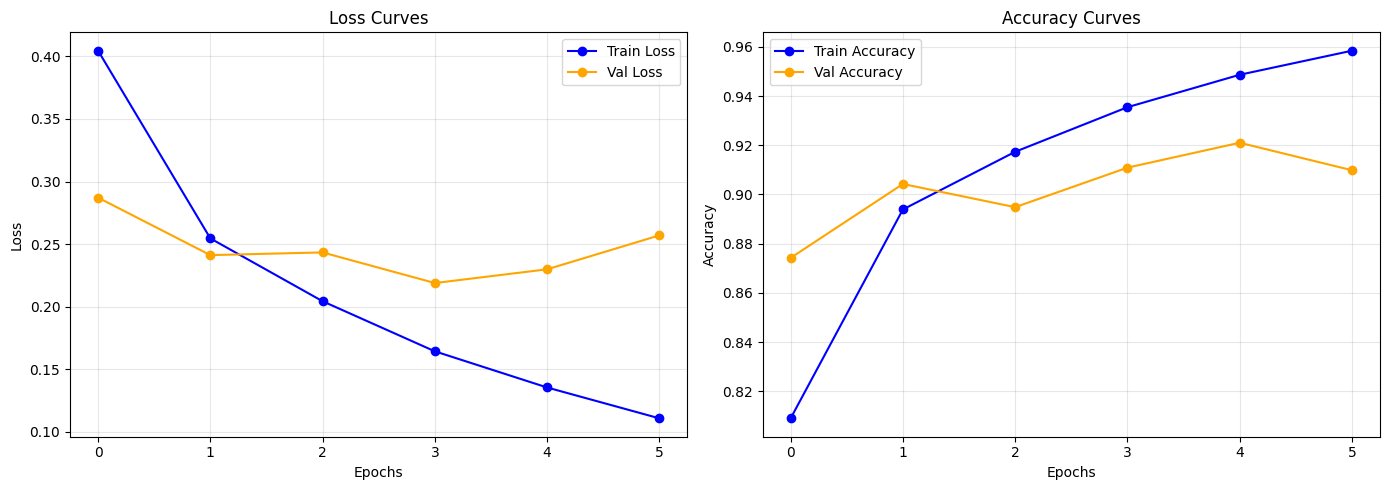

In [20]:
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_training_curves(history: Dict[str, List[float]]) -> None:
    """
    Plots the training and validation loss and accuracy curves over epochs.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', color='orange', marker='o')
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue', marker='o')
    ax2.plot(history['val_acc'], label='Val Accuracy', color='orange', marker='o')
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Execute the plot using the full dataset history
plot_training_curves(training_history_full)

In [21]:
import torch.nn as nn
import torch

def evaluate_test_set(
    model: nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    criterion: nn.Module, 
    device: torch.device,
    target_accuracy: float = 0.82
) -> None:

    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            
            running_loss += loss.item() * input_ids.size(0)
            _, preds = torch.max(logits, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += input_ids.size(0)
            
    final_loss = running_loss / total_samples
    final_accuracy = running_corrects.double() / total_samples
    
    print("="*50)
    print("FINAL TEST SET RESULTS (Unseen Headlines)")
    print("="*50)
    print(f"Test Loss:     {final_loss:.4f}")
    print(f"Test Accuracy: {final_accuracy * 100:.2f}%")
    print("="*50)
    
    if final_accuracy >= target_accuracy:
        print(f"🎉 SUCCESS! You have met or exceeded the {target_accuracy*100:.0f}% target accuracy!")
    else:
        print(f"⚠️ Target not met.")

# Run the evaluation on the full test loader
evaluate_test_set(model_full, test_loader_full, criterion_full, DEVICE, target_accuracy=0.82)

FINAL TEST SET RESULTS (Unseen Headlines)
Test Loss:     0.2208
Test Accuracy: 91.37%
🎉 SUCCESS! You have met or exceeded the 82% target accuracy!



📊 Classification Report:
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.91      0.93      0.92      1498
    Sarcastic (1)       0.92      0.90      0.91      1364

         accuracy                           0.91      2862
        macro avg       0.91      0.91      0.91      2862
     weighted avg       0.91      0.91      0.91      2862



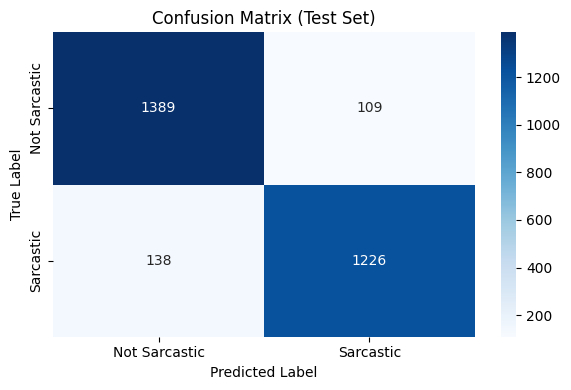

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix_and_report(
    model: nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    device: torch.device
) -> None:
    """
    Plots a confusion matrix and prints a detailed classification report.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(logits, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Print Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Not Sarcastic (0)', 'Sarcastic (1)']))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Sarcastic', 'Sarcastic'], 
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Execute the confusion matrix and report
plot_confusion_matrix_and_report(model_full, test_loader_full, DEVICE)

In [27]:
import gradio as gr
import torch
import torch.nn.functional as F

def predict_sarcasm(headline: str) -> str:
    """
    Takes a raw headline string, tokenizes it, and returns the 
    predicted sarcasm label with a confidence score.
    """
    if not headline.strip():
        return "⚠️ Please enter a valid headline."

    # 1. Tokenize the input (Must match training parameters exactly)
    inputs = tokenizer(
        headline,
        return_tensors="pt",
        max_length=CONFIG['max_length'],
        padding='max_length',
        truncation=True
    )

    # 2. Run Inference
    # FIX: Explicitly pass input_ids and attention_mask to avoid the token_type_ids error
    model_full.eval()
    with torch.no_grad():
        logits = model_full(
            input_ids=inputs['input_ids'].to(DEVICE), 
            attention_mask=inputs['attention_mask'].to(DEVICE)
        )
        
        # Apply softmax to get probabilities for confidence score
        probabilities = F.softmax(logits, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    # 3. Format Output
    label = "Sarcastic 🤣" if predicted_idx.item() == 1 else "Not Sarcastic 📰"
    conf_score = confidence.item() * 100
    
    return f"Prediction: {label}\nConfidence: {conf_score:.2f}%"

# --- Create and Launch Gradio Demo ---
def launch_demo() -> None:
    """Creates and launches the Gradio interface for the Sarcasm Detector."""
    print("🚀 Launching Gradio Demo...")
    
    demo = gr.Interface(
        fn=predict_sarcasm,
        inputs=gr.Textbox(
            lines=2, 
            placeholder="Enter a news headline here...", 
            label="News Headline"
        ),
        outputs=gr.Textbox(label="Model Prediction"),
        title="🤣 Sarcasm Detector (DistilBERT)",
        description="""
        Type any news headline into the box. 
        The model will analyze the linguistic patterns and predict 
        whether the headline is Sarcastic or Not Sarcastic.
        """,
        allow_flagging="never"
    )
    
    # share=True generates a public URL, which is highly recommended 
    # when running inside Colab or the VS Code Colab extension.
    demo.launch(share=True)

# Execute the demo
launch_demo()

🚀 Launching Gradio Demo...


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31fb4a64383abe2112.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
